# Pré-processamento do dataset de água

### Imports e load

In [87]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 4)
sns.set_theme(style="whitegrid")

In [88]:
repo_datasets_path = Path("../PM2025-TSAnomalyDetection/example-timeseries")
zip_path = repo_datasets_path / "aqualog_11_2025.csv.zip"

assert zip_path.exists(), f"Ficheiro não encontrado: {zip_path}"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())
    with z.open(z.namelist()[0]) as f:
        df_agua = pd.read_csv(f)

df_agua.head()

['aqualog_11_2025.csv']


,tstamp,device,valor_l,leitura_l
0,2024-11-08 23:00:00,00PC503015,0,3462110
1,2024-11-08 22:00:00,00PC503015,0,3462110
2,2024-11-08 21:00:00,00PC503015,0,3462110
3,2024-11-08 20:00:00,00PC503015,0,3462110
4,2024-11-08 19:00:00,00PC503015,0,3462110


In [89]:
df_agua["tstamp"] = pd.to_datetime(df_agua["tstamp"])
df_agua = df_agua.sort_values(["device", "tstamp"]).reset_index(drop=True)

print(df_agua.shape)
df_agua.head()

(2603234, 4)


,tstamp,device,valor_l,leitura_l
0,2024-09-19 01:02:00,00PC503015,0,3462110
1,2024-09-19 02:02:00,00PC503015,0,3462110
2,2024-09-19 03:02:00,00PC503015,0,3462110
3,2024-09-19 04:02:00,00PC503015,0,3462110
4,2024-09-19 05:02:00,00PC503015,0,3462110


### Inspeção inicial

In [90]:
print("Número total de registos:", len(df_agua))
print("Número de devices:", df_agua["device"].nunique())
print("Período temporal:", df_agua["tstamp"].min(), "até", df_agua["tstamp"].max())

display(df_agua.info())
display(df_agua.describe(include="all"))

Número total de registos: 2603234
Número de devices: 456
Período temporal: 2024-09-18 01:00:00 até 2025-10-24 00:59:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2603234 entries, 0 to 2603233
Data columns (total 4 columns):
 #   Column     Dtype         
---  ------     -----         
 0   tstamp     datetime64[ns]
 1   device     object        
 2   valor_l    int64         
 3   leitura_l  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 79.4+ MB


None

,tstamp,device,valor_l,leitura_l
count,2603234,2603234,2.603234e+06,2.603234e+06
unique,NaN,456,NaN,NaN
top,NaN,97WWK12134,NaN,NaN
freq,NaN,6994,NaN,NaN
mean,2025-03-01 15:30:23.008519168,NaN,6.755759e+01,4.647876e+06
min,2024-09-18 01:00:00,NaN,-3.105800e+04,-4.330000e+04
25%,2024-12-10 21:58:00,NaN,0.000000e+00,1.044770e+05
50%,2025-02-16 04:58:00,NaN,0.000000e+00,8.037010e+05
75%,2025-04-25 10:59:00,NaN,8.000000e+00,3.298920e+06
max,2025-10-24 00:59:00,NaN,3.706110e+05,1.633660e+08


In [91]:
negativos = (df_agua["valor_l"] < 0).sum()
zeros = (df_agua["valor_l"] == 0).sum()

print("Valores negativos em valor_l:", negativos)
print("Valores zero em valor_l:", zeros)
print("Percentagem de zeros:", round(100 * zeros / len(df_agua), 2), "%")

Valores negativos em valor_l: 3648
Valores zero em valor_l: 1805531
Percentagem de zeros: 69.36 %


count     456.000000
mean     5708.846491
std      1136.565992
min        43.000000
25%      5480.250000
50%      6111.500000
75%      6391.500000
max      6994.000000
dtype: float64

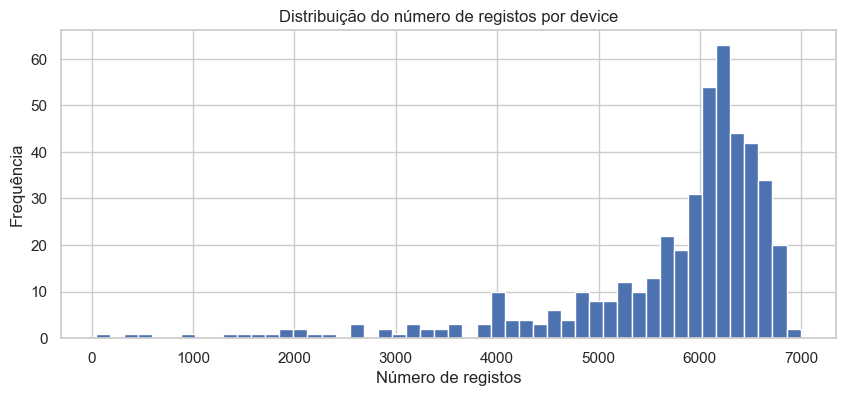

In [92]:
registos_por_device = df_agua.groupby("device").size().sort_values(ascending=False)

display(registos_por_device.describe())

plt.figure(figsize=(10, 4))
plt.hist(registos_por_device, bins=50)
plt.title("Distribuição do número de registos por device")
plt.xlabel("Número de registos")
plt.ylabel("Frequência")
plt.show()

### Seleção de dispositivos utilizáveis

In [93]:
full_time_index = pd.date_range(
    start=df_agua["tstamp"].min(),
    end=df_agua["tstamp"].max(),
    freq="1min"
)

print("Número total de timestamps esperados numa grelha de 1 min:", len(full_time_index))

Número total de timestamps esperados numa grelha de 1 min: 577440


In [94]:
coverage_stats = []

for device, group in df_agua.groupby("device"):
    group = group.sort_values("tstamp")
    observed = group["tstamp"].nunique()
    coverage_pct = 100 * observed / len(full_time_index)

    coverage_stats.append({
        "device": device,
        "n_registos": len(group),
        "n_timestamps_unicos": observed,
        "coverage_pct_1min_grid": coverage_pct,
        "negativos": (group["valor_l"] < 0).sum(),
        "zeros_pct": 100 * (group["valor_l"] == 0).mean(),
        "valor_mean": group["valor_l"].mean(),
        "valor_std": group["valor_l"].std()
    })

coverage_df = pd.DataFrame(coverage_stats).sort_values(
    by="coverage_pct_1min_grid", ascending=False
)

coverage_df.head(10)

,device,n_registos,n_timestamps_unicos,coverage_pct_1min_grid,negativos,zeros_pct,valor_mean,valor_std
4,97WWK12134,6994,6994,1.211208,0,96.811553,64.027738,904.787894
14,C17SC007397,6888,6888,1.192851,0,100.000000,0.000000,0.000000
44,C18SC002133,6850,6850,1.186270,0,99.751825,2.547883,79.037284
5,98WWKI12645,6815,6815,1.180209,0,98.723404,0.168745,1.674492
15,C17SC007432,6814,6814,1.180036,0,42.104491,79.197828,110.192872
331,I21JC037663T,6813,6813,1.179863,0,0.000000,384.993395,229.098752
13,C17SC007379,6812,6812,1.179690,0,100.000000,0.000000,0.000000
0,00PC503015,6811,6811,1.179516,0,87.813831,0.378946,2.400225
203,I14JE002622G,6809,6809,1.179170,0,64.723161,159.782641,293.097808
166,H21VA420783K,6785,6785,1.175014,2,32.232867,54.374503,110.627738


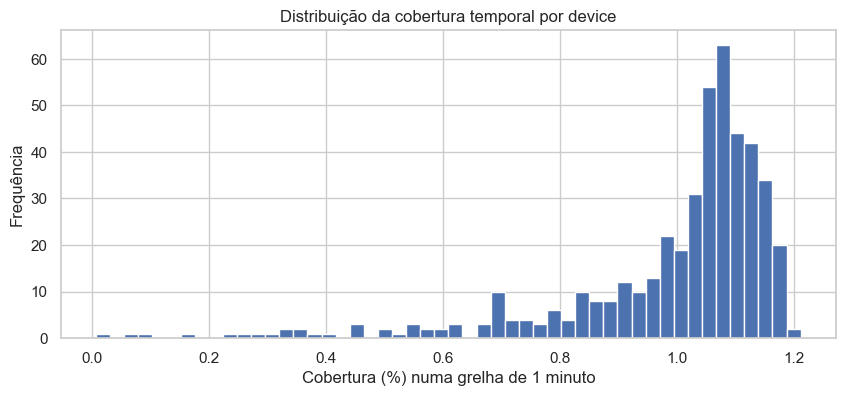

In [95]:
plt.figure(figsize=(10, 4))
plt.hist(coverage_df["coverage_pct_1min_grid"], bins=50)
plt.title("Distribuição da cobertura temporal por device")
plt.xlabel("Cobertura (%) numa grelha de 1 minuto")
plt.ylabel("Frequência")
plt.show()

In [96]:
selected_devices = coverage_df[
    (coverage_df["coverage_pct_1min_grid"] >= 1.0) &
    (coverage_df["n_registos"] >= 5000)
]["device"].tolist()

print("Número de devices selecionados:", len(selected_devices))
selected_devices[:20]

Número de devices selecionados: 305


['97WWK12134',
 'C17SC007397',
 'C18SC002133',
 '98WWKI12645',
 'C17SC007432',
 'I21JC037663T',
 'C17SC007379',
 '00PC503015',
 'I14JE002622G',
 'H21VA420783K',
 'I19JC029874',
 'I17JE096914',
 'I21LA091899',
 'H20VA222016',
 'I19JC065537',
 'I23JC095867',
 'I21JC029765B',
 'D19BA341196',
 'H21VA420473Z',
 'C18SC005957']

In [97]:
df_agua_sel = df_agua[df_agua["device"].isin(selected_devices)].copy()

print("Shape após seleção de devices:", df_agua_sel.shape)
print("Devices restantes:", df_agua_sel["device"].nunique())

Shape após seleção de devices: (1922075, 4)
Devices restantes: 305


### Regularização temporal e resampling

In [98]:
gap_stats = []

for device, group in df_agua_sel.groupby("device"):
    diffs = group.sort_values("tstamp")["tstamp"].diff().dropna()
    top_gaps = diffs.value_counts().head(5).to_dict()

    gap_stats.append({
        "device": device,
        "dominant_gap": diffs.mode().iloc[0] if not diffs.empty else pd.NaT,
        "median_gap": diffs.median() if not diffs.empty else pd.NaT,
        "n_unique_gaps": diffs.nunique()
    })

gap_df = pd.DataFrame(gap_stats)
gap_df.head()

,device,dominant_gap,median_gap,n_unique_gaps
0,00PC503015,0 days 01:00:00,0 days 01:00:00,55
1,10045021,0 days 01:00:00,0 days 01:00:00,19
2,2124881J,0 days 01:00:00,0 days 01:00:00,46
3,94CWK04576,0 days 01:00:00,0 days 01:00:00,31
4,97WWK12134,0 days 01:00:00,0 days 01:00:00,32


In [99]:
gap_df["dominant_gap"].value_counts().head(10)

dominant_gap
0 days 01:00:00    305
Name: count, dtype: int64

In [100]:
target_freq = "1h"

series_resampled = []

for device, group in df_agua_sel.groupby("device"):
    g = group.sort_values("tstamp").set_index("tstamp")

    g = g.groupby(level=0)["valor_l"].sum().to_frame()

    g_resampled = g.resample(target_freq).sum(min_count=1)

    g_resampled["device"] = device
    g_resampled = g_resampled.reset_index()

    series_resampled.append(g_resampled)

df_resampled = pd.concat(series_resampled, ignore_index=True)

print(df_resampled.shape)
df_resampled.head()

(2842892, 3)


,tstamp,valor_l,device
0,2024-09-19 01:00:00,0.0,00PC503015
1,2024-09-19 02:00:00,0.0,00PC503015
2,2024-09-19 03:00:00,0.0,00PC503015
3,2024-09-19 04:00:00,0.0,00PC503015
4,2024-09-19 05:00:00,0.0,00PC503015


### Tratamento de inconsistências e valores negativos

In [101]:
neg_before = (df_resampled["valor_l"] < 0).sum()
print("Negativos antes:", neg_before)

df_resampled.loc[df_resampled["valor_l"] < 0, "valor_l"] = np.nan

neg_after = (df_resampled["valor_l"] < 0).sum()
print("Negativos depois:", neg_after)

Negativos antes: 3308
Negativos depois: 0


### Tratamento de valores em falta

In [102]:
pivot_resampled = df_resampled.pivot(index="tstamp", columns="device", values="valor_l")

missing_pct_after_resample = pivot_resampled.isna().mean() * 100
missing_pct_after_resample.sort_values().head(10)

device
97WWK12134      27.327515
C17SC007397     28.428928
C18SC002133     28.823774
98WWKI12645     29.187448
C17SC007432     29.197839
I21JC037663T    29.208229
C17SC007379     29.218620
00PC503015      29.229011
I14JE002622G    29.249792
H21VA420783K    29.519950
dtype: float64

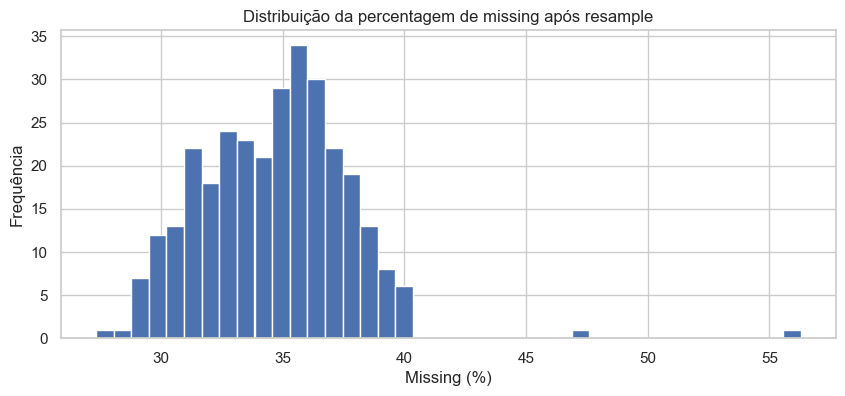

In [103]:
plt.figure(figsize=(10, 4))
plt.hist(missing_pct_after_resample, bins=40)
plt.title("Distribuição da percentagem de missing após resample")
plt.xlabel("Missing (%)")
plt.ylabel("Frequência")
plt.show()

In [104]:
devices_final = missing_pct_after_resample[
    missing_pct_after_resample <= 95
].index.tolist()

print("Devices finais:", len(devices_final))

Devices finais: 305


In [105]:
pivot_final = pivot_resampled[devices_final].copy()
print(pivot_final.shape)

(9624, 305)


In [106]:
pivot_interp = pivot_final.copy()

pivot_interp = pivot_interp.interpolate(
    method="time",
    limit=3,
    limit_direction="both"
)

missing_after_interp = pivot_interp.isna().mean() * 100
missing_after_interp.describe()

count    305.000000
mean      31.703187
std        2.231385
min       25.374065
25%       29.821280
50%       31.577307
75%       33.676226
max       36.741480
dtype: float64

In [107]:
pivot_filled = pivot_interp.fillna(0)

print("Missing restantes:", pivot_filled.isna().sum().sum())

Missing restantes: 0


### Tratamento de outliers

In [108]:
def cap_outliers_iqr(series, factor=3.0):
    s = series.copy()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    return s.clip(lower=lower, upper=upper)

In [109]:
pivot_capped = pivot_filled.copy()

for col in pivot_capped.columns:
    pivot_capped[col] = cap_outliers_iqr(pivot_capped[col], factor=3.0)

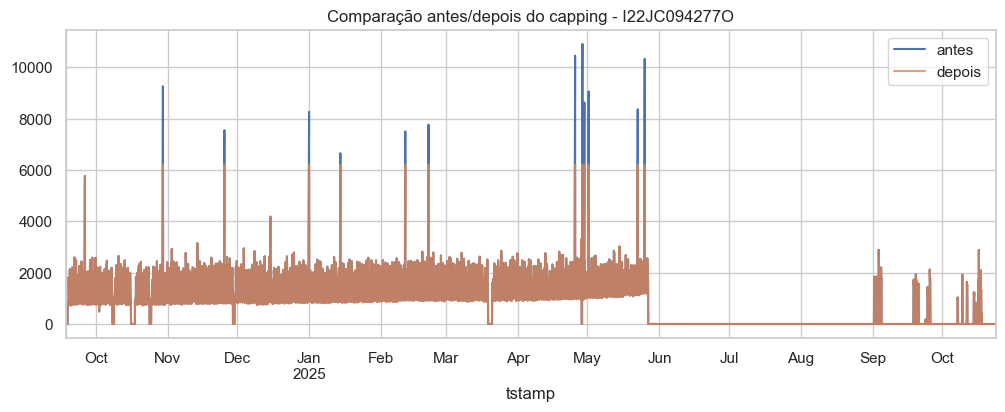

In [110]:
device_example = "I22JC094277O"

plt.figure(figsize=(12, 4))
pivot_filled[device_example].plot(label="antes")
pivot_capped[device_example].plot(label="depois", alpha=0.8)
plt.title(f"Comparação antes/depois do capping - {device_example}")
plt.legend()
plt.show()

### Normalização

In [111]:
def robust_scale_series(series):
    median = series.median()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        return series - median
    return (series - median) / iqr

In [112]:
pivot_scaled = pivot_capped.copy()

for col in pivot_scaled.columns:
    pivot_scaled[col] = robust_scale_series(pivot_scaled[col])

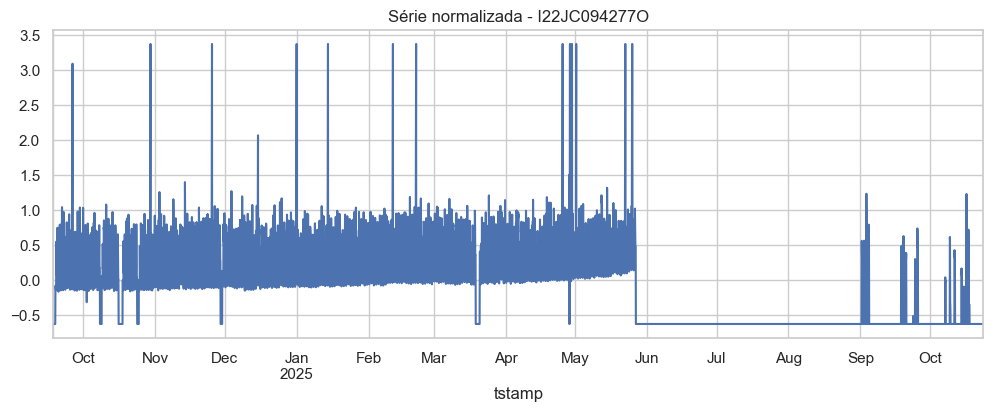

In [113]:
plt.figure(figsize=(12, 4))
pivot_scaled[device_example].plot()
plt.title(f"Série normalizada - {device_example}")
plt.show()

### Export do dataset processado

In [114]:
df_clean_long = (
    pivot_scaled
    .reset_index()
    .melt(id_vars="tstamp", var_name="device", value_name="valor_l_scaled")
)

df_clean_long.head()

,tstamp,device,valor_l_scaled
0,2024-09-18 01:00:00,00PC503015,0.0
1,2024-09-18 02:00:00,00PC503015,0.0
2,2024-09-18 03:00:00,00PC503015,0.0
3,2024-09-18 04:00:00,00PC503015,0.0
4,2024-09-18 05:00:00,00PC503015,0.0


In [115]:
output_dir = Path("../data_processed")
output_dir.mkdir(parents=True, exist_ok=True)

In [116]:
output_path_long = output_dir / "agua_clean_5min_long.csv"
df_clean_long.to_csv(output_path_long, index=False)

print("Guardado em:", output_path_long)

Guardado em: ..\data_processed\agua_clean_5min_long.csv


In [117]:
output_path_wide = output_dir / "agua_clean_5min_wide.csv"
pivot_scaled.to_csv(output_path_wide)

print("Guardado em:", output_path_wide)

Guardado em: ..\data_processed\agua_clean_5min_wide.csv


### Resumo das transformações aplicadas

In [118]:
summary = {
    "n_registos_originais": len(df_agua),
    "n_devices_originais": df_agua["device"].nunique(),
    "n_devices_pos_primeiro_filtro": len(selected_devices),
    "n_devices_finais": len(devices_final),
    "target_freq": target_freq,
    "negativos_iniciais": int((df_agua["valor_l"] < 0).sum()),
    "missing_total_apos_resample": int(pivot_resampled.isna().sum().sum()),
    "missing_total_apos_interpolacao": int(pivot_interp.isna().sum().sum()),
    "missing_total_final": int(pivot_filled.isna().sum().sum())
}

summary

{'n_registos_originais': 2603234,
 'n_devices_originais': 456,
 'n_devices_pos_primeiro_filtro': 305,
 'n_devices_finais': 305,
 'target_freq': '1h',
 'negativos_iniciais': 3648,
 'missing_total_apos_resample': 1016570,
 'missing_total_apos_interpolacao': 930590,
 'missing_total_final': 0}

In [119]:
summary_df = pd.DataFrame([summary])
summary_df

,n_registos_originais,n_devices_originais,n_devices_pos_primeiro_filtro,n_devices_finais,target_freq,negativos_iniciais,missing_total_apos_resample,missing_total_apos_interpolacao,missing_total_final
0,2603234,456,305,305,1h,3648,1016570,930590,0


In [120]:
summary_df.to_csv(output_dir / "agua_preprocessing_summary.csv", index=False)

## Conclusão do Pré-processamento

Neste notebook foi realizado o pré-processamento do dataset de consumo de água, com o objetivo de preparar os dados para tarefas de deteção de anomalias.

Foram aplicadas as seguintes etapas principais:

- Seleção de dispositivos com cobertura temporal e volume de dados suficientes;
- Regularização temporal das séries para uma frequência horária (1h);
- Tratamento de valores negativos, considerados inconsistentes, convertendo-os em valores em falta;
- Interpolação limitada de falhas curtas e preenchimento dos restantes valores em falta;
- Limitação de outliers com base no intervalo interquartil (IQR);
- Normalização robusta por série temporal.

Após estas transformações, obteve-se um conjunto de séries temporais estruturadas, consistentes e prontas para aplicação de métodos de deteção de anomalias.

Importa referir que o dataset apresenta elevada esparsidade e uma grande proporção de valores nulos ou zero, o que constitui um desafio relevante para modelação e será tido em consideração nas etapas seguintes.

Os dados processados foram exportados em formato "wide" e "long", permitindo a sua utilização em diferentes abordagens de modelação.